# Activity 2.1 - Overview of `sklearn` for modeling

### Part 1 - Intro https://www.youtube.com/watch?v=0B5eIE_1vpU&t=188s
-   Give a more detailed overview of “data —> model —> predict”
Load data, split it into features (X) and target (y), train a model on the data, then use the trained model to make predictions on new data.

-   What is the data?  How is it partitioned?
Data is a dataset with features and a target variable. It's partitioned into training set (to teach the model) and test set (to evaluate performance).

-   Data phases? What are the two phases the model?  
Training phase: model learns patterns. Testing phase: model is evaluated on unseen data.

-   How are the these phases implemented in sklearn?  
Use .fit() method to train, .predict() method to make predictions. All sklearn models follow this pattern.
Make a notebook and follow along with the author

BELOW- load boston is not availiable in sklearn.datasets. We used scikit-learn in 326 so I have prior understanding

-   BIG IDEA: What is the advantage of using the sklearn API?
Consistent interface. Every model uses the same fit/predict methods, so you can easily swap different algorithms without changing your code structure.



In [1]:
from sklearn.datasets import load_boston

ImportError: 
`load_boston` has been removed from scikit-learn since version 1.2.

The Boston housing prices dataset has an ethical problem: as
investigated in [1], the authors of this dataset engineered a
non-invertible variable "B" assuming that racial self-segregation had a
positive impact on house prices [2]. Furthermore the goal of the
research that led to the creation of this dataset was to study the
impact of air quality but it did not give adequate demonstration of the
validity of this assumption.

The scikit-learn maintainers therefore strongly discourage the use of
this dataset unless the purpose of the code is to study and educate
about ethical issues in data science and machine learning.

In this special case, you can fetch the dataset from the original
source::

    import pandas as pd
    import numpy as np

    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[:

### kNN and preprocessing intro https://youtu.be/0B5eIE_1vpU?si=Ge7pwkWhCp4-8OJw&t=689
2.  Give a summary of how the kNN model works on a regression problem.
kNN finds the k nearest neighbors to a data point and averages their target values to make a prediction. It uses distance to determine "nearness".

⁃   Explain why different scales might be problematic for kNN
kNN uses distance calculations. If one feature has a much larger scale, it dominates the distance metric and the other features get ignored. Scaling puts all features on equal footing.

⁃   Explain the expanded view of the model as a pipeline.
A pipeline chains preprocessing steps (like scaling) with the model. Data flows through each step sequentially: raw data → scaler → model → predictions.  

⁃   Why is the sklearn pipeline implementation so this nice?
Pipelines ensure preprocessing steps are applied consistently to training and test data. They prevent data leakage and make code cleaner and more reproducible.

⁃   Why are there () after each element of the pipeline?
The () creates an instance of the class. You're passing objects (instances), not class definitions, to the pipeline.


### intro to model validation https://youtu.be/0B5eIE_1vpU?si=_4qAN_9xOTKYRe-k&t=1057

- **Why is the plot of the predicted vs actual y values too optimistic? How does using one neighbor illustrate this problem?**
Testing on training data. With k=1, each point is its own nearest neighbor, giving perfect predictions (100% accuracy) that don't reflect real-world performance.

- **Give an overview of splitting the data up for prediction and train.**
Split data into two parts: train the model on one part, test on the other part (data the model has never seen). This gives honest performance estimates.

- **Discuss how cross validation is implemented in sklearn and how this expands our understanding of what a model is.**
CV splits data into k folds, trains on k-1 folds and tests on the remaining fold, rotating through all folds. This gives multiple performance estimates. A "model" includes both the algorithm and its hyperparameters.

- **How do we get at list of parameters for an sklearn model?**
Use model.get_params() to see all available parameters for tuning.

- **Explain how we can access and inspect the CV results.**
After GridSearchCV.fit(), access results via cv_results_ attribute. It's a dictionary with performance metrics for each parameter combination tested.

- **Give an overview of the complete pattern ("set of lego bricks") that we will aim for when using sklearn.**
1) Load data, 2) Create pipeline with preprocessing + model, 3) Set up GridSearchCV with parameter grid, 4) Fit on training data, 5) Evaluate on test data, 6) Inspect results.

- **[Iverson's crazy aside] Normally we avoid print statements like the plague, but printing the Boston data set's description is an exception. Explain why printing this description is acceptable.**
Dataset descriptions are metadata meant to be read by humans. They explain what the data represents. Unlike printing raw data, this provides context without cluttering output.

- **Why isn't this pattern enough to make us "proper data scientists"?**
Technical skills are just the start. You need domain knowledge, ethics, communication skills, and critical thinking to use models responsibly and effectively.

- **What problem did the author highlight in the Boston housing data set?**
Ethical issues: the dataset included a problematic variable related to race that could perpetuate discrimination. Data science requires awareness of social implications.

- **What the short coming of using a grid search?**
Computationally expensive. Tests every combination exhaustively. With many parameters or large ranges, it becomes impractical.

- **What is the "hard part" of working as a data scientist? Provide a list of the additional things a data scientist should consider.**
Hard part: asking the right questions and understanding the problem context.
Additional considerations: Understanding the business/domain problem, data quality and bias, ethical implications, model interpretability, communication with stakeholders, reproducibility, deployment and maintenance.



Now using the diabetes dataset instead of California housing.

In [2]:
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
import pandas as pd

diabetes = load_diabetes()
X = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y = pd.Series(diabetes.target)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score

(knn := KNeighborsRegressor(n_neighbors=5)).fit(X_train, y_train)
r2_no_scale = r2_score(y_test, knn.predict(X_test))

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

(pipe := Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsRegressor(n_neighbors=5))])).fit(X_train, y_train)
r2_scaled = r2_score(y_test, pipe.predict(X_test))

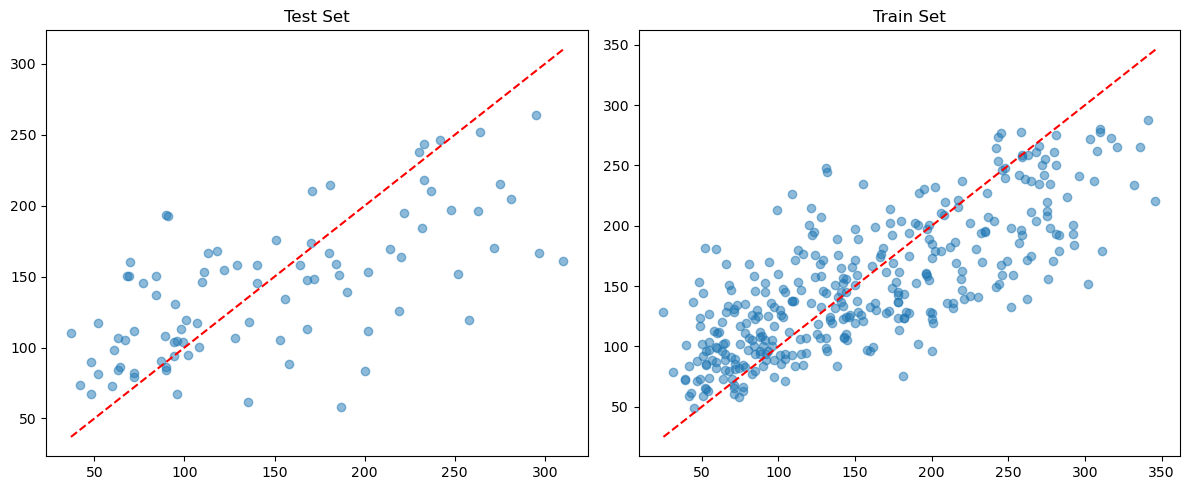

In [6]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.scatter(y_test, pipe.predict(X_test), alpha=0.5)
ax1.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
ax1.set_title('Test Set')
ax2.scatter(y_train, pipe.predict(X_train), alpha=0.5)
ax2.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
ax2.set_title('Train Set')
plt.tight_layout()

In [7]:
from sklearn.model_selection import GridSearchCV

(grid := GridSearchCV(
    pipe, 
    {'knn__n_neighbors': [3, 5, 7, 10], 'knn__weights': ['uniform', 'distance']},
    cv=5, 
    scoring='r2'
)).fit(X_train, y_train)

,estimator,Pipeline(step...Regressor())])
,param_grid,"{'knn__n_neighbors': [3, 5, ...], 'knn__weights': ['uniform', 'distance']}"
,scoring,'r2'
,n_jobs,None
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


In [8]:
(results := pd.DataFrame(grid.cv_results_)
    [['param_knn__n_neighbors', 'param_knn__weights', 'mean_test_score', 'rank_test_score']]
    .sort_values('rank_test_score'))

,param_knn__n_neighbors,param_knn__weights,mean_test_score,rank_test_score
7,10,distance,0.384403,1
6,10,uniform,0.383786,2
5,7,distance,0.364781,3
4,7,uniform,0.364766,4
3,5,distance,0.319246,5
2,5,uniform,0.317546,6
1,3,distance,0.263454,7
0,3,uniform,0.260523,8
